In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Read grayscale image

image = cv2.imread("cat.png", 0)

In [16]:
# Flatten image into 1D array
pixels = image.flatten()

In [17]:
# Step 1: Calculate Frequency

frequency = {}

for pixel in pixels:
    if pixel in frequency:
        frequency[pixel] += 1
    else:
        frequency[pixel] = 1

In [18]:
# Step 2: Create Huffman Node

class Node:

    def __init__(self, value, freq):
        self.value = value
        self.freq = freq
        self.left = None
        self.right = None

In [19]:
# Step 3: Build Huffman Tree Manually

nodes = []

for value in frequency:
    nodes.append(Node(value, frequency[value]))

while len(nodes) > 1:

    # Sort nodes by frequency
    nodes.sort(key=lambda x: x.freq)

    left = nodes.pop(0)
    right = nodes.pop(0)

    parent = Node(None, left.freq + right.freq)
    parent.left = left
    parent.right = right

    nodes.append(parent)

root = nodes[0]

In [20]:
# Step 4: Generate Huffman Codes

codes = {}

def generate_code(node, code):

    if node is None:
        return

    if node.value is not None:
        codes[node.value] = code
        return

    generate_code(node.left, code + "0")
    generate_code(node.right, code + "1")

generate_code(root, "")

In [21]:
# Step 5: Encode Image

encoded = ""

for pixel in pixels:
    encoded += codes[pixel]

In [22]:
# Step 6: Decode Image

decoded_pixels = []

current = root

for bit in encoded:

    if bit == '0':
        current = current.left
    else:
        current = current.right

    if current.value is not None:
        decoded_pixels.append(current.value)
        current = root

decoded_image = np.array(decoded_pixels, dtype=np.uint8)
decoded_image = decoded_image.reshape(image.shape)

In [23]:
# Compression Statistics

original_bits = len(pixels) * 8
compressed_bits = len(encoded)

compression_ratio = original_bits / compressed_bits

print("Original Size (bits):", original_bits)
print("Compressed Size (bits):", compressed_bits)
print("Compression Ratio:", round(compression_ratio,2), ":1")

Original Size (bits): 3092640
Compressed Size (bits): 2917754
Compression Ratio: 1.06 :1


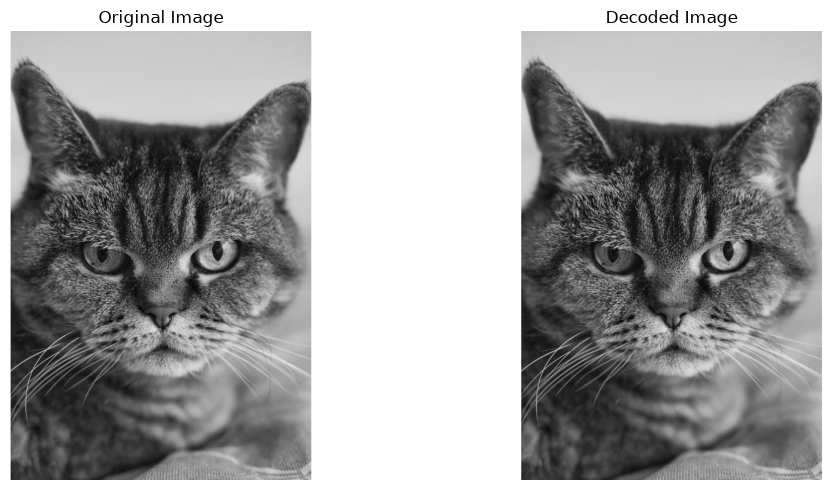

In [24]:
# Display Images

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(decoded_image, cmap='gray')
plt.title("Decoded Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# Print Huffman Codes

print("\nHuffman Codes")

for key in sorted(codes):
    print(f"{key:3d} : {codes[key]}")


Huffman Codes
  1 : 000101001111100100
  2 : 000101001111100101
  3 : 0001010011111000
  4 : 000101001110101
  5 : 000101001111101
  6 : 00010100111011
  7 : 00010100111001
  8 : 11101111010111
  9 : 1110111101001
 10 : 1110111101010
 11 : 101110101110
 12 : 101110101111
 13 : 10111010110
 14 : 11101111011
 15 : 1011101010
 16 : 1101110111
 17 : 010000000
 18 : 011100101
 19 : 101011111
 20 : 110111010
 21 : 111100000
 22 : 111011100
 23 : 00101000
 24 : 01001011
 25 : 01100111
 26 : 01111110
 27 : 10100100
 28 : 10111001
 29 : 11000011
 30 : 11000111
 31 : 11011001
 32 : 11100010
 33 : 11101011
 34 : 11100110
 35 : 11111000
 36 : 11110100
 37 : 11110111
 38 : 0000011
 39 : 0001011
 40 : 0001111
 41 : 0010011
 42 : 0011101
 43 : 0100001
 44 : 0011110
 45 : 0101010
 46 : 0100100
 47 : 0101111
 48 : 0101101
 49 : 0110101
 50 : 0110110
 51 : 0101110
 52 : 0110100
 53 : 0111011
 54 : 0110111
 55 : 0110010
 56 : 0101100
 57 : 0101011
 58 : 0100111
 59 : 0100110
 60 : 0101001
 61 : 0011011
